## Zadanie domowe: BBHE i DSIHE

W klasycznym wyrównywaniu histogramu HE  po wykonaniu operacji jasność obrazu ulega zmianie.
Dało się to zaobserwować podczas przeprowadzonych eksperymentów.
Jeśli nie to należy uruchomić skrypt z sekcji A i zwrócić na to uwagę.
Średnia jasność dąży do środkowego poziomu szarości.
Jest to wada i dlatego klasyczne HE ma ograniczone zastosowanie.

Powstało sporo metod, które eliminują to niekorzystne zjawisko.
Najprostsze z nich polegają na dekompozycji obrazu wejściowego na dwa podobrazy (wg. pewnego kryterium).
Następnie operacja HE wykonywana jest dla tych podobrazów.

Dwie znane z literatury metody to:
- Bi-Histogram Equalization
- DSIHE - Dualistic Sub-Image Histogram Equalization

W metodzie BBHE za kryterium podziału przyjmuje się średnią jasność w obrazie.
W DSIHE obraz dzieli się na dwa podobrazy o takiej samej liczbie pikseli (jaśniejszych i ciemniejszych).

W ramach zadania należy zaimplementować wybraną metodę: BBHE lub DSIHE (ew. obie).

1. Wczytaj obraz *jet.bmp* i wylicz jego histogram.
2. W kolejnym kroku należy wyznaczyć próg podziału obrazu na dwa podobrazy (*lm*).
3. Dla BBHE wyznacz średnią jasność obrazu. Dla DSIHE można wykorzystać histogram skumulowany.
Należy znaleźć poziom jasności który znajduje się "w połowie" histogramu skumulowanego.
W tym celu warto stworzyć tablicę, zawierającą moduł histogramu skumulowanego pomniejszonego o połowę liczby pikseli.
Następnie znaleźć minimum.
4. Dalej należy podzielić histogram oryginalnego obrazu na dwa histogramy *H1* i *H2*.
Dla każdego z nich wyliczyć histogram skumulowany ($C_1$ i $C_2$) i wykonać normalizację.
Normalizacja polega na podzieleniu każdego histogramu przez jego największy element.
5. Na podstawie histogramów skumulowanych należy stworzyć przekształcenie LUT.
Należy tak przeskalować $C_1$ i $C_2$, aby uzyskać jednorodne przekształcenie.
Tablicę $C_1$ wystarczy pomnożyć przez próg podziału.
Tablicę $C_2$ należy przeskalować do przedziału: $<lm+1; 255>$, gdzie $lm$ jest progiem podziału.<br>
$C_{1n} = (lm)*C1;$<br>
$C_{2n} = lm+1 + (255-lm-1)*C2;$<br>
Następnie dwie części tablicy przekodowań należy połączyć.
6. Ostatecznie należy wykonać operację LUT i wyświetlić wynik wyrównywania histogramu.
Porównaj wynik operacji BBHE lub DSIHE z klasycznym HE.

--2025-03-19 23:14:22--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/03_Histogram/jet.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 263224 (257K) [image/bmp]
Saving to: 'jet.bmp'

     0K .......... .......... .......... .......... .......... 19% 1,02M 0s
    50K .......... .......... .......... .......... .......... 38% 3,86M 0s
   100K .......... .......... .......... .......... .......... 58% 1,16M 0s
   150K .......... .......... .......... .......... .......... 77% 3,07M 0s
   200K .......... .......... .......... .......... .......... 97% 3,08M 0s
   250K .......                                               100% 8,96M=0,1s

2025-03-19 23:14:22 (1,86 MB/s) - 'jet.bmp' saved [263224/263224]



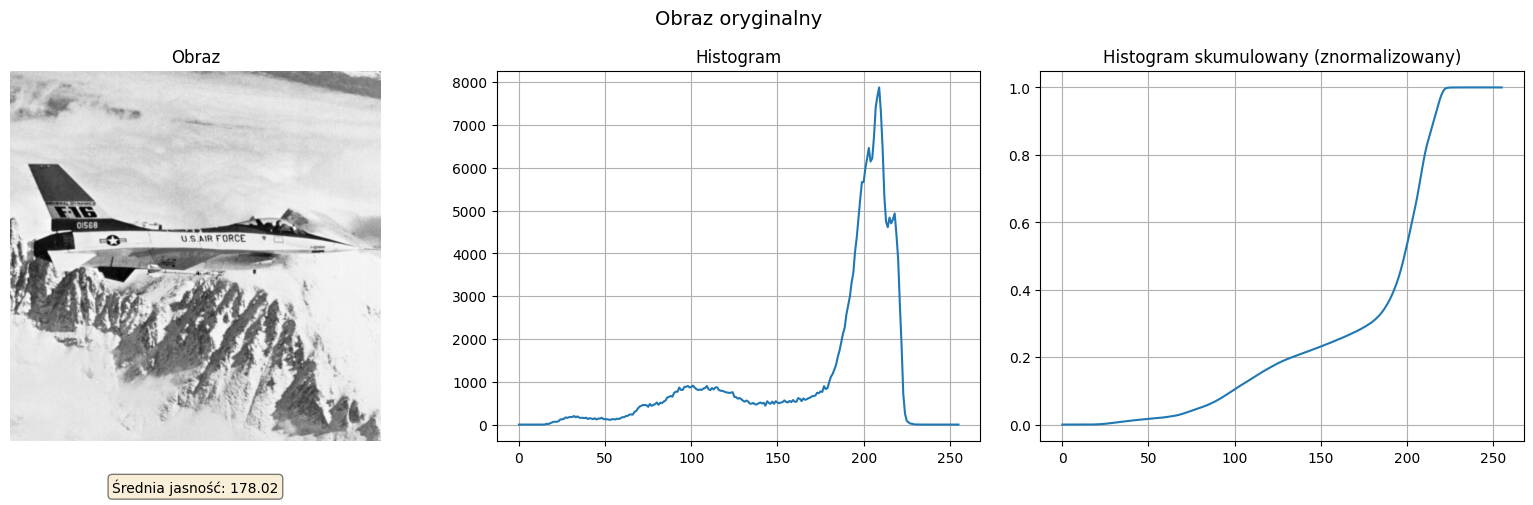

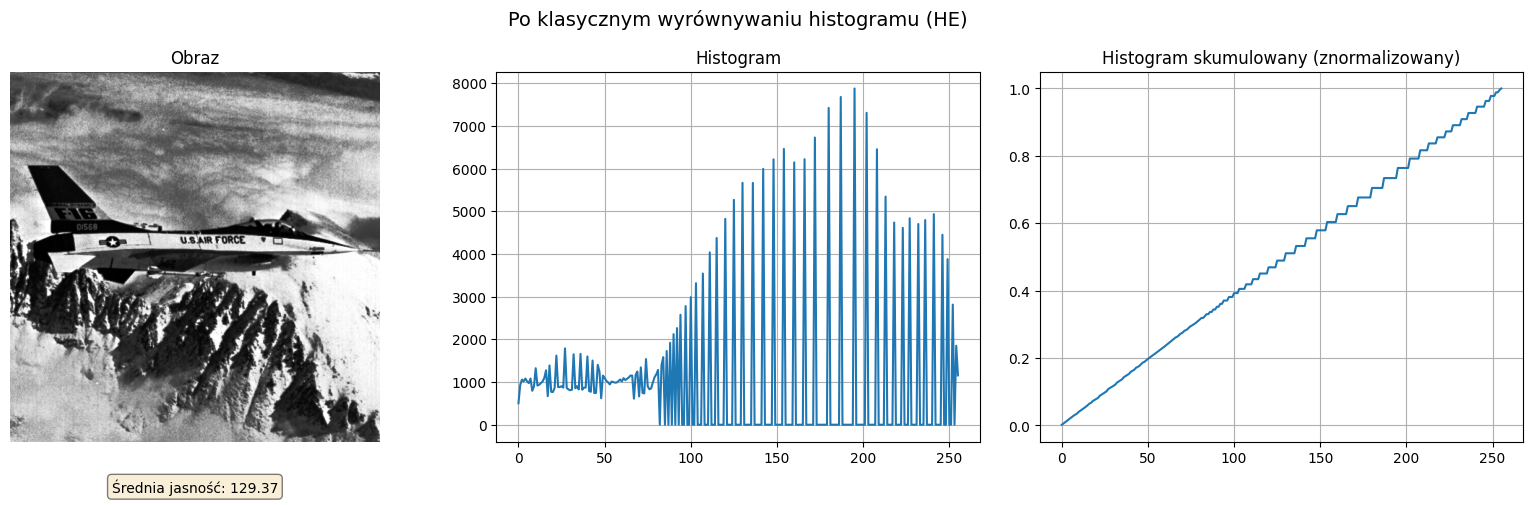

Próg podziału BBHE (średnia jasność): 178


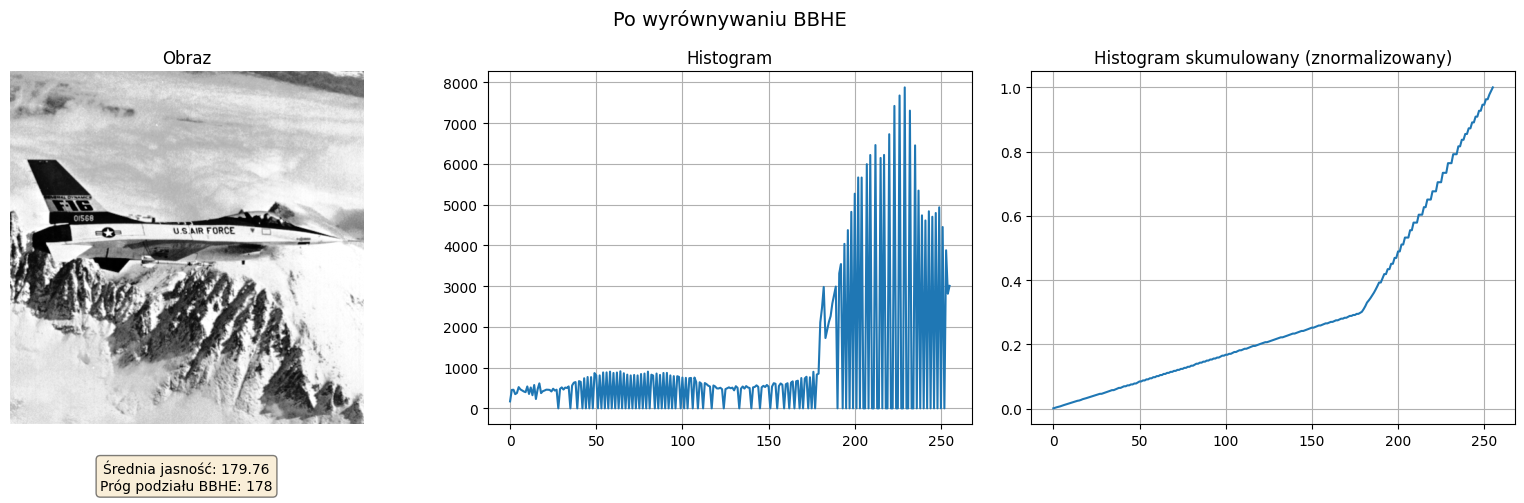

Próg podziału DSIHE (mediana jasności): 199


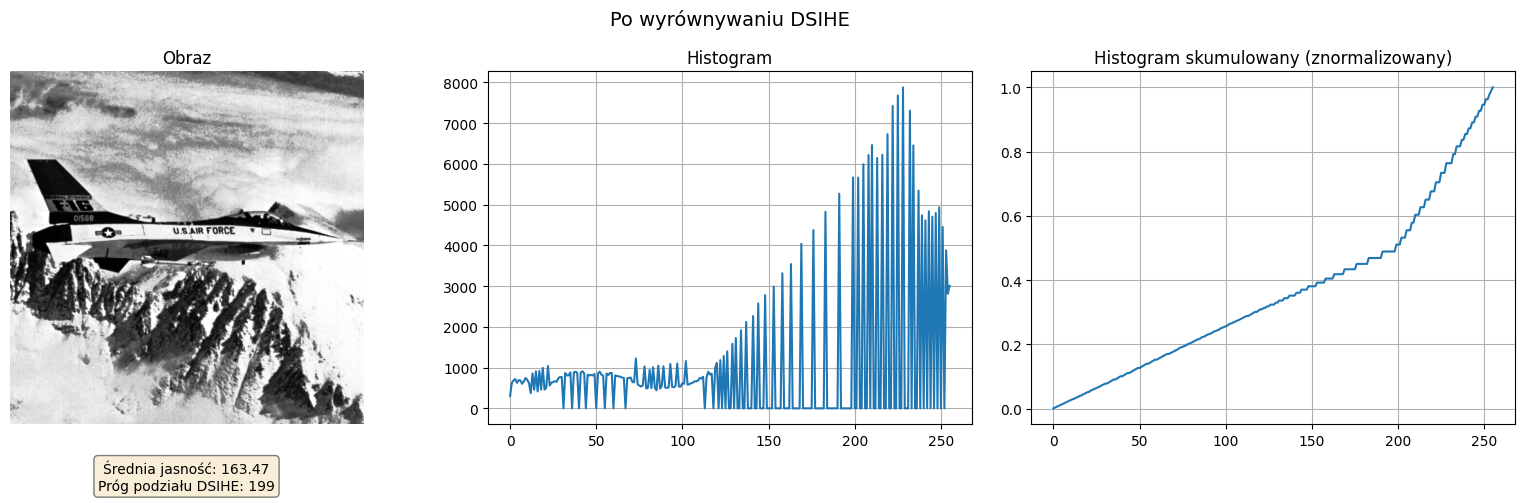

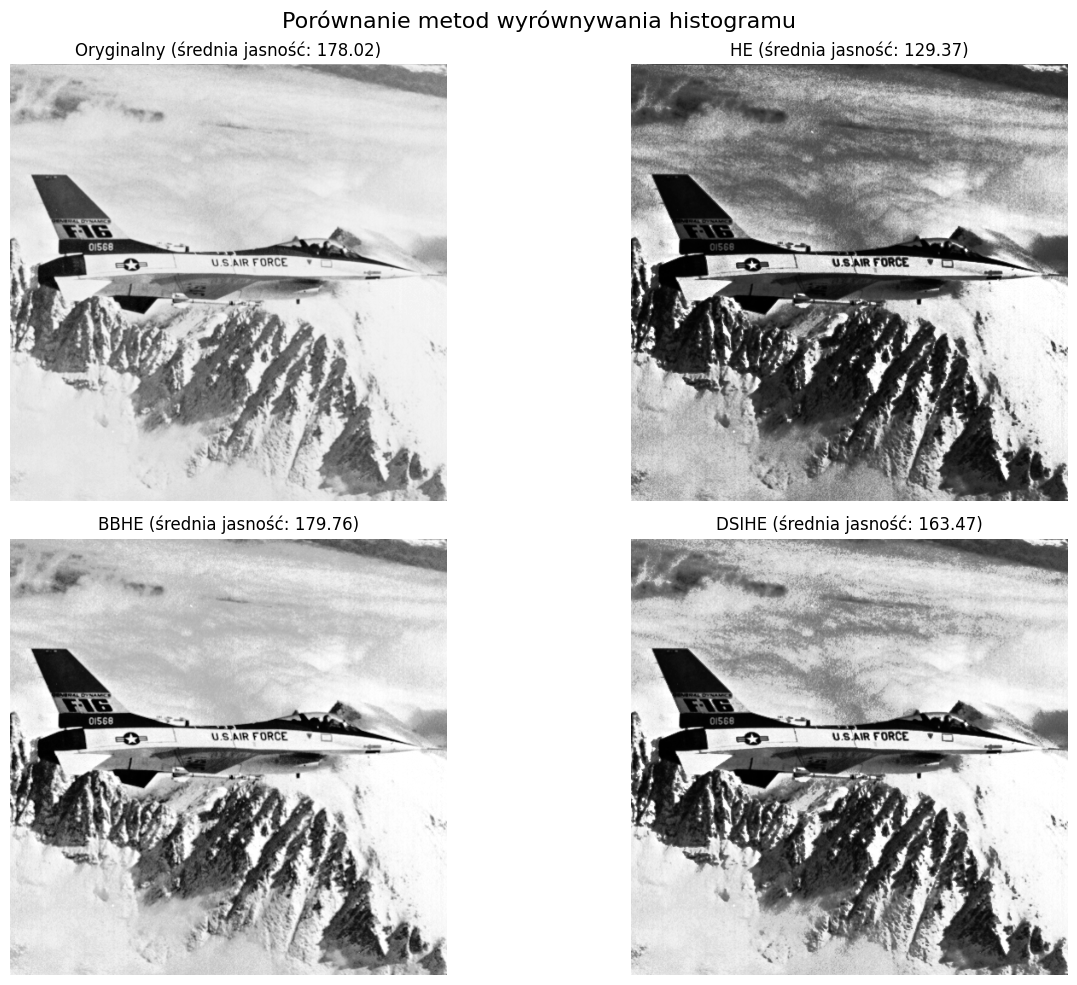


Podsumowanie średnich jasności:
Oryginalny obraz: 178.02
HE: 129.37
BBHE: 179.76 (Próg: 178)
DSIHE: 163.47 (Próg: 199)

Zmiany średniej jasności względem obrazu oryginalnego:
HE: -48.65
BBHE: 1.74
DSIHE: -14.55


In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

if not os.path.exists("jet.bmp"):
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/03_Histogram/jet.bmp --no-check-certificate

obraz = cv2.imread('jet.bmp', cv2.IMREAD_GRAYSCALE)
histogram = cv2.calcHist([obraz], [0], None, [256], [0, 256]).flatten()
histogram_skum = histogram.cumsum()

def wyswietl_obraz_i_histogram(obraz, tytul, srednia_jasnosc, prog=None, metoda=None):
    hist = cv2.calcHist([obraz], [0], None, [256], [0, 256])
    hist_skum = hist.cumsum()
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(tytul, fontsize=14)
    
    ax1.imshow(obraz, cmap='gray')
    ax1.set_title('Obraz')
    ax1.axis('off')
    
    info_text = f"Średnia jasność: {srednia_jasnosc:.2f}"
    if prog is not None and metoda is not None:
        info_text += f"\nPróg podziału {metoda}: {prog}"
    ax1.text(0.5, -0.1, info_text, transform=ax1.transAxes, 
             horizontalalignment='center', verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax2.plot(hist)
    ax2.set_title('Histogram')
    ax2.grid(True)
    
    ax3.plot(hist_skum / hist_skum.max())
    ax3.set_title('Histogram skumulowany (znormalizowany)')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

wyswietl_obraz_i_histogram(obraz, "Obraz oryginalny", obraz.mean())

def bbhe(obraz):
    lm = np.mean(obraz).astype(np.uint8)
    print(f"Próg podziału BBHE (średnia jasność): {lm}")
    
    maska_dolna = obraz <= lm
    maska_gorna = obraz > lm
    
    podobraz_dolny = obraz[maska_dolna]
    podobraz_gorny = obraz[maska_gorna]
    
    hist_dolny = np.zeros(lm + 1)
    for i in range(lm + 1):
        hist_dolny[i] = np.sum(podobraz_dolny == i)
    
    hist_gorny = np.zeros(256 - lm - 1)
    for i in range(lm + 1, 256):
        hist_gorny[i - (lm + 1)] = np.sum(podobraz_gorny == i)
    
    if hist_dolny.sum() > 0:
        c1 = hist_dolny.cumsum() / hist_dolny.sum()
    else:
        c1 = np.zeros_like(hist_dolny)
        
    if hist_gorny.sum() > 0:
        c2 = hist_gorny.cumsum() / hist_gorny.sum()
    else:
        c2 = np.zeros_like(hist_gorny)
    
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(lm + 1):
        lut[i] = np.round(lm * c1[i])
    
    for i in range(lm + 1, 256):
        lut[i] = np.round(lm + 1 + (255 - lm - 1) * c2[i - (lm + 1)])
    
    return cv2.LUT(obraz, lut), lm

def dsihe(obraz):
    hist = cv2.calcHist([obraz], [0], None, [256], [0, 256]).flatten()
    hist_skum = hist.cumsum()
    
    polowa_pikseli = obraz.size / 2
    diff = np.abs(hist_skum - polowa_pikseli)
    lm = np.argmin(diff)
    print(f"Próg podziału DSIHE (mediana jasności): {lm}")
    
    maska_dolna = obraz <= lm
    maska_gorna = obraz > lm
    
    podobraz_dolny = obraz[maska_dolna]
    podobraz_gorny = obraz[maska_gorna]
    
    hist_dolny = np.zeros(lm + 1)
    for i in range(lm + 1):
        hist_dolny[i] = np.sum(podobraz_dolny == i)
    
    hist_gorny = np.zeros(256 - lm - 1)
    for i in range(lm + 1, 256):
        hist_gorny[i - (lm + 1)] = np.sum(podobraz_gorny == i)
    
    if hist_dolny.sum() > 0:
        c1 = hist_dolny.cumsum() / hist_dolny.sum()
    else:
        c1 = np.zeros_like(hist_dolny)
        
    if hist_gorny.sum() > 0:
        c2 = hist_gorny.cumsum() / hist_gorny.sum()
    else:
        c2 = np.zeros_like(hist_gorny)
    
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(lm + 1):
        lut[i] = np.round(lm * c1[i])
    
    for i in range(lm + 1, 256):
        lut[i] = np.round(lm + 1 + (255 - lm - 1) * c2[i - (lm + 1)])
    
    return cv2.LUT(obraz, lut), lm

obraz_he = cv2.equalizeHist(obraz)
wyswietl_obraz_i_histogram(obraz_he, "Po klasycznym wyrównywaniu histogramu (HE)", obraz_he.mean())

obraz_bbhe, prog_bbhe = bbhe(obraz)
wyswietl_obraz_i_histogram(obraz_bbhe, "Po wyrównywaniu BBHE", obraz_bbhe.mean(), prog_bbhe, "BBHE")

obraz_dsihe, prog_dsihe = dsihe(obraz)
wyswietl_obraz_i_histogram(obraz_dsihe, "Po wyrównywaniu DSIHE", obraz_dsihe.mean(), prog_dsihe, "DSIHE")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Porównanie metod wyrównywania histogramu", fontsize=16)

axes[0, 0].imshow(obraz, cmap='gray')
axes[0, 0].set_title(f"Oryginalny (średnia jasność: {obraz.mean():.2f})")
axes[0, 0].axis('off')

axes[0, 1].imshow(obraz_he, cmap='gray')
axes[0, 1].set_title(f"HE (średnia jasność: {obraz_he.mean():.2f})")
axes[0, 1].axis('off')

axes[1, 0].imshow(obraz_bbhe, cmap='gray')
axes[1, 0].set_title(f"BBHE (średnia jasność: {obraz_bbhe.mean():.2f})")
axes[1, 0].axis('off')

axes[1, 1].imshow(obraz_dsihe, cmap='gray')
axes[1, 1].set_title(f"DSIHE (średnia jasność: {obraz_dsihe.mean():.2f})")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nPodsumowanie średnich jasności:")
print(f"Oryginalny obraz: {obraz.mean():.2f}")
print(f"HE: {obraz_he.mean():.2f}")
print(f"BBHE: {obraz_bbhe.mean():.2f} (Próg: {prog_bbhe})")
print(f"DSIHE: {obraz_dsihe.mean():.2f} (Próg: {prog_dsihe})")

print("\nZmiany średniej jasności względem obrazu oryginalnego:")
print(f"HE: {obraz_he.mean() - obraz.mean():.2f}")
print(f"BBHE: {obraz_bbhe.mean() - obraz.mean():.2f}")
print(f"DSIHE: {obraz_dsihe.mean() - obraz.mean():.2f}")